### utilities

In [25]:
def plot_loss_landscape_with_gd_trajectory(
    X, y, gd_history, w_closed, true_intercept, true_slope,
    intercept_range=None, slope_range=None,
    grid_resolution=100, figsize=(10, 8),
    contour_levels=30, cmap='viridis'
):
    """
    Visualize the loss landscape with gradient descent trajectory overlay.
    
    Parameters:
    -----------
    X : np.ndarray
        Design matrix of shape (n_samples, 2) with [1, x] columns
    y : np.ndarray
        Target values of shape (n_samples,)
    gd_history : dict
        Dictionary with 'weights' key containing list of weight arrays from gradient descent
    w_closed : np.ndarray
        Closed-form solution weights of shape (2,)
    true_intercept : float
        True intercept parameter
    true_slope : float
        True slope parameter
    intercept_range : np.ndarray, optional
        Range of intercept values for grid. Default: np.linspace(-10, 10, grid_resolution)
    slope_range : np.ndarray, optional
        Range of slope values for grid. Default: np.linspace(0, 7, grid_resolution)
    grid_resolution : int, optional
        Resolution of the grid for loss computation (default: 100)
    figsize : tuple, optional
        Figure size (default: (10, 8))
    contour_levels : int, optional
        Number of contour levels (default: 30)
    cmap : str, optional
        Colormap for contours (default: 'viridis')
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    ax : matplotlib.axes.Axes
        The axes object
    """
    # Set default ranges if not provided
    if intercept_range is None:
        intercept_range = np.linspace(-10, 10, grid_resolution)
    if slope_range is None:
        slope_range = np.linspace(0, 7, grid_resolution)
    
    # Create a grid of weight values
    intercepts_mesh, slopes_mesh = np.meshgrid(intercept_range, slope_range)
    
    # Compute loss at each point on the grid (vectorized)
    w_grid = np.vstack([intercepts_mesh.ravel(), slopes_mesh.ravel()])
    y_pred_grid = X @ w_grid
    loss_vals = np.mean((y_pred_grid - y[:, np.newaxis]) ** 2, axis=0)
    loss_grid = loss_vals.reshape(intercepts_mesh.shape)
    
    # Create contour plot
    fig, ax = plt.subplots(figsize=figsize)
    contour_levels_array = np.linspace(loss_grid.min(), loss_grid.max(), contour_levels)
    contour = ax.contour(intercepts_mesh, slopes_mesh, loss_grid, 
                        levels=contour_levels_array, cmap=cmap, alpha=0.6)
    ax.clabel(contour, inline=True, fontsize=8)
    contourf = ax.contourf(intercepts_mesh, slopes_mesh, loss_grid, 
                          levels=contour_levels_array, cmap=cmap, alpha=0.3)
    
    # Extract gradient descent trajectory
    gd_trajectory = np.array(gd_history['weights'])
    
    # Plot gradient descent trajectory
    ax.plot(gd_trajectory[:, 0], gd_trajectory[:, 1], 'r-', linewidth=2, 
           label='GD trajectory', marker='o', markersize=4)
    ax.plot(gd_trajectory[0, 0], gd_trajectory[0, 1], 'go', markersize=10, 
           label='Start (random)', zorder=5)
    ax.plot(gd_trajectory[-1, 0], gd_trajectory[-1, 1], 'r*', markersize=20, 
           label='End (optimized)', zorder=5)
    
    # Plot closed-form solution
    ax.plot(w_closed[0], w_closed[1], 'b^', markersize=12, 
           label='Closed-form solution', zorder=5)
    
    # Plot true parameters
    ax.plot(true_intercept, true_slope, 'k+', markersize=15, markeredgewidth=2, 
           label='True parameters', zorder=5)
    
    # Configure axes and labels
    ax.set_xlabel('Intercept ($w_0$)', fontsize=12)
    ax.set_ylabel('Slope ($w_1$)', fontsize=12)
    ax.set_title('Loss Landscape and Gradient Descent Trajectory', fontsize=13, fontweight='bold')
    ax.set_xlim(intercept_range.min() - 0.2, intercept_range.max() + 0.2)
    ax.set_ylim(slope_range.min() - 0.2, slope_range.max() + 0.2)
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(contourf, ax=ax)
    cbar.set_label('Mean Squared Error', fontsize=11)
    
    plt.tight_layout()
    
    return fig, ax

# Linear Regression with One Feature

This notebook demonstrates how to fit a simple linear regression model with one dependent variable. We establish the modeling goal, define the mean squared error loss, derive the closed-form solution, and visualize gradient descent converging toward the optimal parameters.

In [2]:
!pip install -q seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

np.random.seed(42)

## Goal and Synthetic Dataset
We will recover a linear relationship of the form $$y = w_0 + w_1 x + \varepsilon$$ using noisy observations. 
The ground-truth slope is 3.5 and the intercept is -2.0.

In [26]:
n_samples = 5
noise_scale = 4.0
true_intercept = -2.0
true_slope = 3.5

x = np.linspace(0, 10, n_samples)
noise = np.random.normal(loc=0.0, scale=noise_scale, size=n_samples)
y = true_intercept + true_slope * x + noise

x[:5], y[:5]

(array([ 0. ,  2.5,  5. ,  7.5, 10. ]),
 array([-2.93654783, 13.06685126, 18.56973892, 22.37210246, 35.17024017]))

## Visualizing the Data

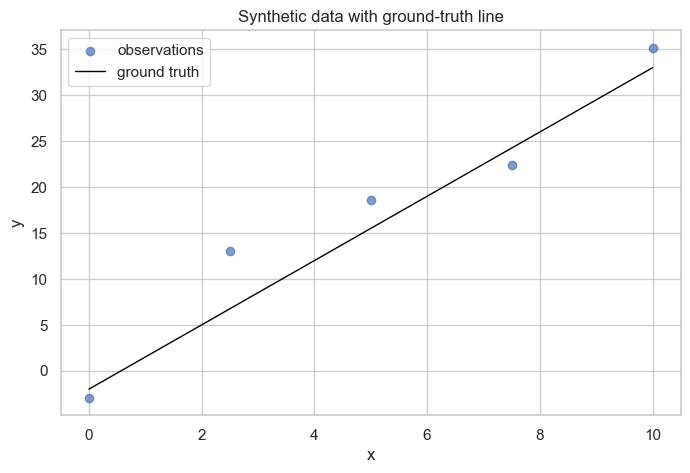

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7, label='observations')
plt.plot(x, true_intercept + true_slope * x, color='black', linewidth=1, label='ground truth')
plt.title('Synthetic data with ground-truth line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## Model, Loss, and Closed-Form Solution
The hypothesis function is $\hat{y} = w_0 + w_1 x$. We minimize the mean squared error (MSE) loss:
$${\cal L}(w_0, w_1) = \frac{1}{n} \sum_{i=1}^n (\hat{y}_i - y_i)^2.$$
For a single feature, the optimal parameters admit an analytic solution using the normal equations.

In [28]:
def design_matrix(x_values: np.ndarray) -> np.ndarray:
    return np.c_[np.ones_like(x_values), x_values]

# TODO: implement the design matrix using np.concatenate or np.hstack instead of np.c_
def design_matrix(x_values: np.ndarray) -> np.ndarray:
    # why reshape? because we need to convert the 1D array into a 2D array with one column, 
    # so that we can concatenate it with the intercept column
    intercept_column = np.ones_like(x_values).reshape(-1, 1)
    slope_column = x_values.reshape(-1, 1)
    return np.hstack([intercept_column, slope_column])

X = design_matrix(x)
w_closed = np.linalg.pinv(X.T @ X) @ X.T @ y
w = np.linalg.lstsq(X, y, rcond=None)[0]

print(f"Closed-form solution: intercept={w_closed[0]:.2f}, slope={w_closed[1]:.2f}")
print(f"NumPy lstsq solution: intercept={w[0]:.2f}, slope={w[1]:.2f}")

Closed-form solution: intercept=0.14, slope=3.42
NumPy lstsq solution: intercept=0.14, slope=3.42


### Comparing estimated line to Ground Truth

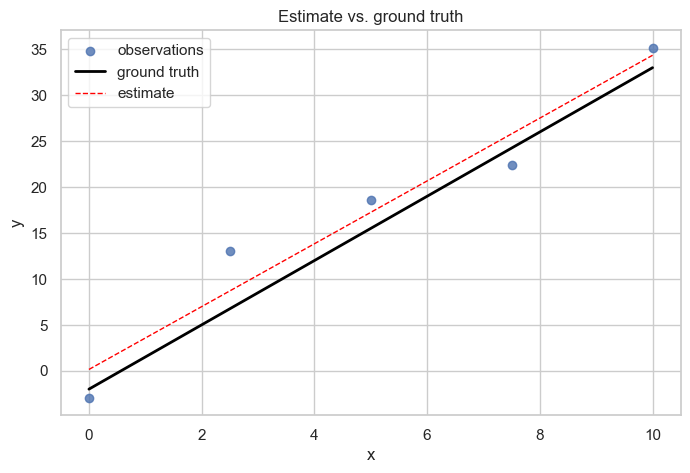

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.8, label='observations')
plt.plot(x, true_intercept + true_slope * x, color='black', linewidth=2, label='ground truth')
plt.plot(x, w[0] + w[1] * x, color='red', linestyle='--', linewidth=1, label='estimate')
plt.title('Estimate vs. ground truth')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## Gradient Descent Optimization
To approximate the same solution iteratively, we minimize the MSE loss with gradient descent. The gradients for intercept and slope are:
$${\partial {\cal L} \over \partial w_0} = \frac{2}{n} \sum (\hat{y}_i - y_i), \qquad {\partial {\cal L} \over \partial w_1} = \frac{2}{n} \sum (\hat{y}_i - y_i) x_i.$$

In [30]:
def gradient_descent(X, y, learning_rate=0.05, n_iter=20):
    w = np.zeros(X.shape[1])
    history = {'weights': [], 'loss': []}
    for _ in range(n_iter):
        y_pred = X @ w
        residuals = y_pred - y
        loss = np.mean(residuals ** 2)
        grad = (2 / len(y)) * (X.T @ residuals)
        w -= learning_rate * grad
        history['weights'].append(w.copy())
        history['loss'].append(loss)
    return w, history

gd_weights, gd_history = gradient_descent(X, y, learning_rate=0.01, n_iter=1000)
gd_intercept, gd_slope = gd_weights
gd_intercept, gd_slope

(np.float64(0.14514550987004587), np.float64(3.420694717798307))

### Visualizing Gradient Descent Trajectory

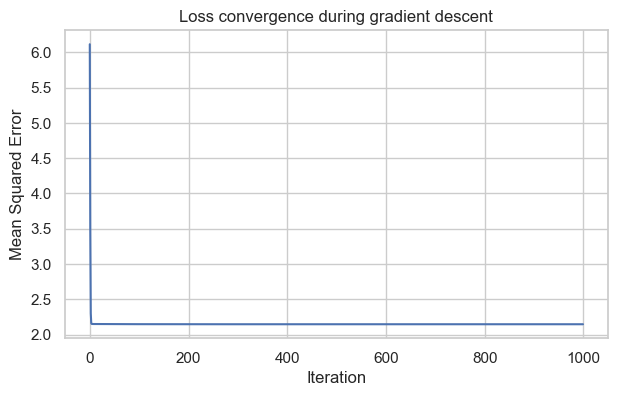

In [31]:
plt.figure(figsize=(7, 4))
plt.plot(np.log(gd_history['loss']))
plt.title('Loss convergence during gradient descent')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.show()

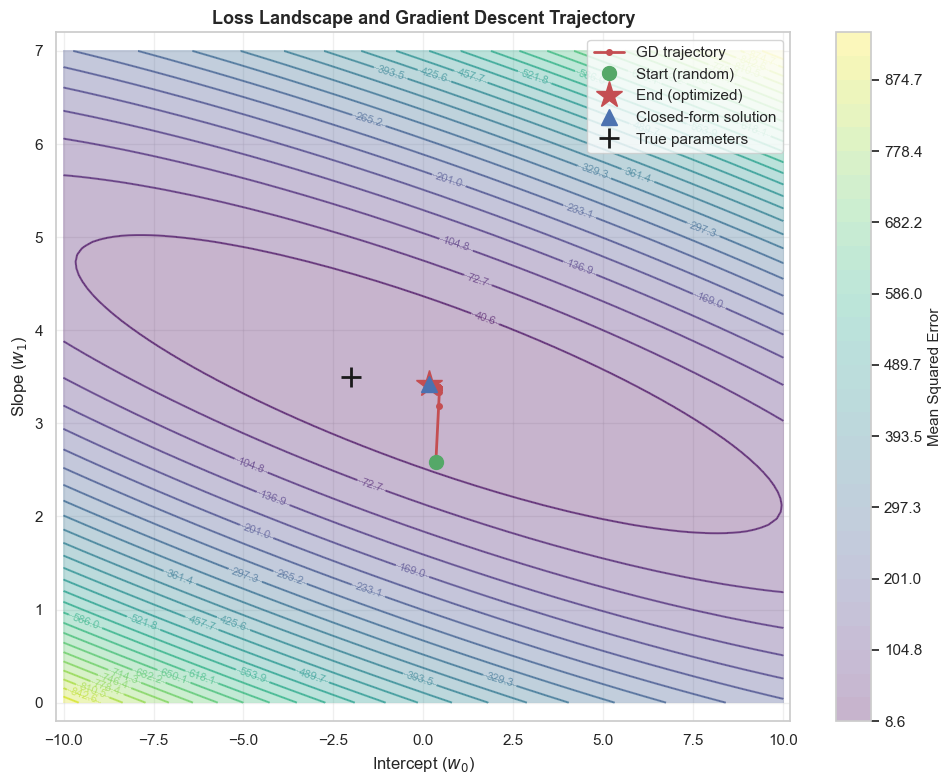

In [32]:
# Loss landscape: contour plot with gradient descent trajectory overlay
fig, ax = plot_loss_landscape_with_gd_trajectory(
    X, y, gd_history, w_closed, 
    true_intercept, true_slope
)
plt.show()

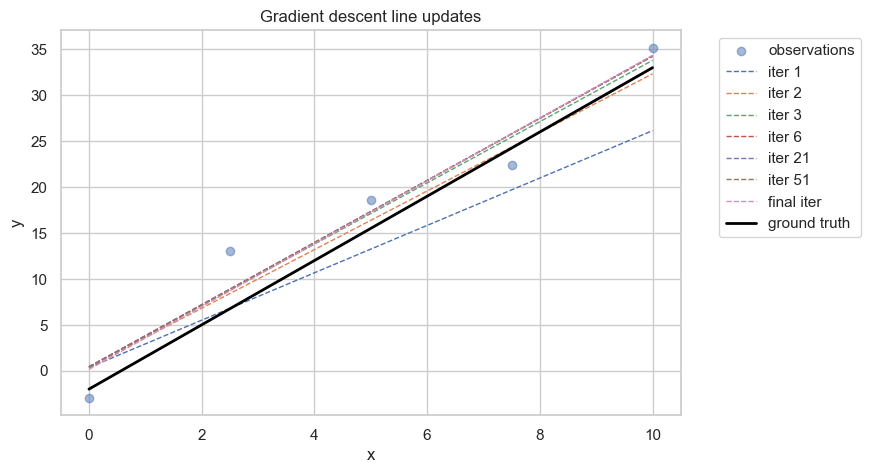

In [33]:
iterations_to_plot = [0, 1, 2, 5, 20, 50, len(gd_history['loss']) - 1]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5, label='observations')
for idx in iterations_to_plot:
    w_iter = gd_history['weights'][idx]
    intercept_iter, slope_iter = w_iter
    label = f'iter {idx + 1}' if idx != iterations_to_plot[-1] else 'final iter'
    plt.plot(x, intercept_iter + slope_iter * x, linestyle='--', linewidth=1, label=label)
plt.plot(x, true_intercept + true_slope * x, color='black', linewidth=2, label='ground truth')
plt.title('Gradient descent line updates')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Comparing Solutions
Both the analytic and gradient-based approaches converge to parameters close to the ground truth, with gradient descent approaching the optimum iteratively.

In [34]:
print(f'True intercept:      {true_intercept:.3f}')
print(f'True slope:          {true_slope:.3f}')
print(f'Closed-form intercept: {w_closed[0]:.3f}')
print(f'Closed-form slope:     {w_closed[1]:.3f}')
print(f'Gradient descent intercept: {gd_intercept:.3f}')
print(f'Gradient descent slope:     {gd_slope:.3f}')

True intercept:      -2.000
True slope:          3.500
Closed-form intercept: 0.145
Closed-form slope:     3.421
Gradient descent intercept: 0.145
Gradient descent slope:     3.421


## Polynomial Regression Extension
We can enrich the hypothesis with polynomial basis functions to capture non-linear trends. Here we fit a cubic polynomial using the normal equation and compare it to the linear fit.

In [35]:
def design_matrix_poly(x_values: np.ndarray, degree: int) -> np.ndarray:
    # Create a design matrix for polynomial regression up to the specified degree
    # The first column is the intercept (all ones), and the next columns are x, x^2, ..., x^degree
    columns = [np.ones_like(x_values)]
    for power in range(1, degree + 1):
        columns.append(x_values ** power)
    return np.column_stack(columns)

poly_degree = 5
X_poly = design_matrix_poly(x, poly_degree)
w_poly = np.linalg.pinv(X_poly.T @ X_poly) @ X_poly.T @ y
poly_predictions = X_poly @ w_poly

print("Polynomial coefficients: w_poly =", w_poly)
for i, coeff in enumerate(w_poly):
    if i == 0:
        print(f'w{i} (intercept) = {coeff:.3f}')
    else:
        print(f'w{i} (x^{i}) = {coeff:.3f}')

Polynomial coefficients: w_poly = [-2.93654787  3.38620361  3.67748864 -1.35956485  0.16466164 -0.00650556]
w0 (intercept) = -2.937
w1 (x^1) = 3.386
w2 (x^2) = 3.677
w3 (x^3) = -1.360
w4 (x^4) = 0.165
w5 (x^5) = -0.007


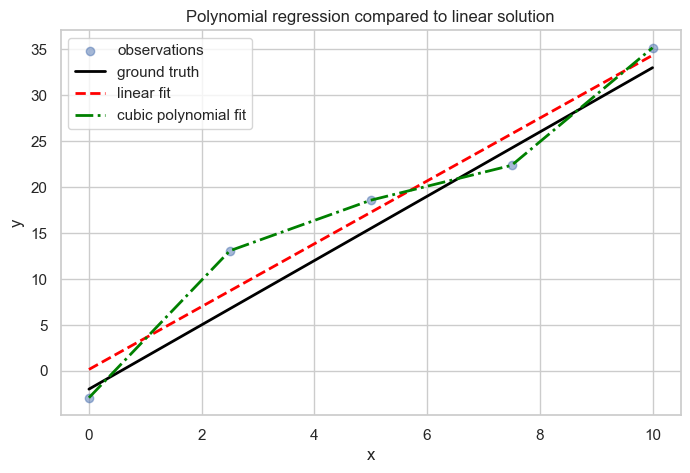

In [36]:
closed_intercept, closed_slope = w_closed

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5, label='observations')
plt.plot(x, true_intercept + true_slope * x, color='black', linewidth=2, label='ground truth')
plt.plot(x, closed_intercept + closed_slope * x, color='red', linestyle='--', linewidth=2, label='linear fit')
plt.plot(x, poly_predictions, color='green', linestyle='-.', linewidth=2, label='cubic polynomial fit')
plt.title('Polynomial regression compared to linear solution')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

The polynomial fit recovers coefficients close to zero for higher-order terms because the underlying relationship is linear. This illustrates how polynomial features can generalize while respecting the data.

## Residual Diagnostics
Residual analysis helps verify model assumptions. We inspect residuals for the closed-form linear fit and the cubic polynomial fit.

In [37]:
residuals_linear = y - (closed_intercept + closed_slope * x)
residuals_poly = y - poly_predictions
print(f'Linear residual mean: {residuals_linear.mean():.4f}')
print(f'Polynomial residual mean: {residuals_poly.mean():.4f}')

Linear residual mean: -0.0000
Polynomial residual mean: 0.0000


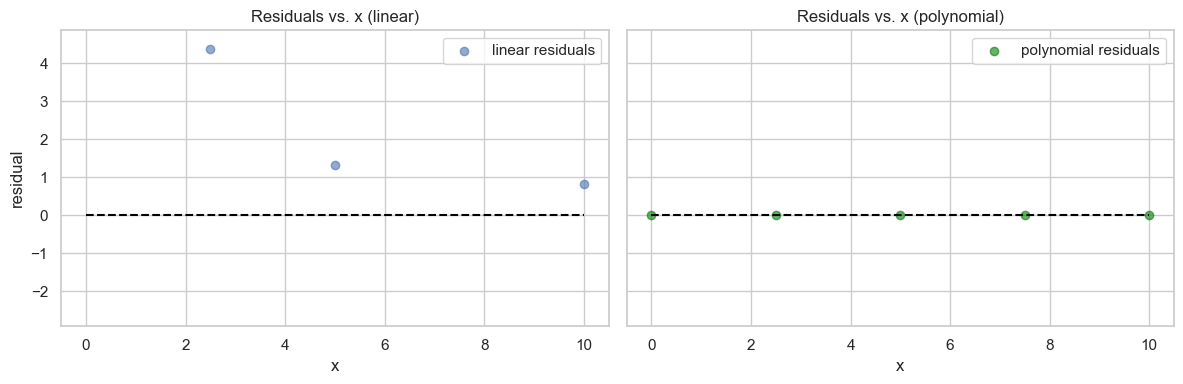

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].scatter(x, residuals_linear, alpha=0.6, label='linear residuals')
axes[0].hlines(0, x.min(), x.max(), colors='black', linestyles='--')
axes[0].set_title('Residuals vs. x (linear)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('residual')
axes[0].legend()

axes[1].scatter(x, residuals_poly, alpha=0.6, color='green', label='polynomial residuals')
axes[1].hlines(0, x.min(), x.max(), colors='black', linestyles='--')
axes[1].set_title('Residuals vs. x (polynomial)')
axes[1].set_xlabel('x')
axes[1].legend()
plt.tight_layout()

# TODO: make both plots share the same y-axis limits for better comparison
y_min = min(residuals_linear.min(), residuals_poly.min())
y_max = max(residuals_linear.max(), residuals_poly.max())
axes[0].set_ylim(y_min+0.5, y_max+0.5)
axes[1].set_ylim(y_min+0.5, y_max+0.5)
plt.show()

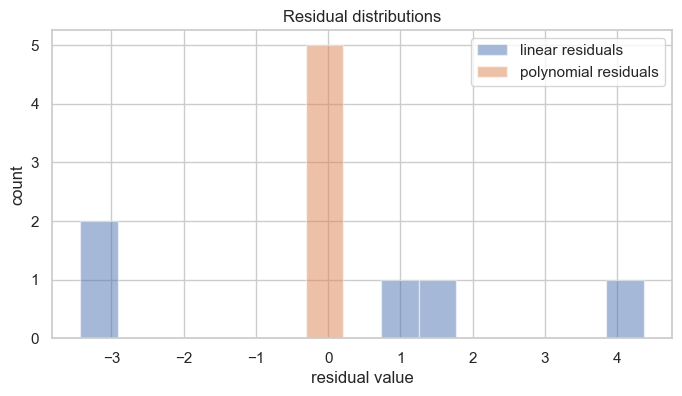

In [39]:
#TODO: make both histograms share the same bin edges for better comparison
bin_edges = np.histogram_bin_edges(np.concatenate([residuals_linear, residuals_poly]), bins=15)
plt.figure(figsize=(8, 4))
plt.hist(residuals_linear, bins=bin_edges, alpha=0.5, label='linear residuals')
plt.hist(residuals_poly, bins=bin_edges, alpha=0.5, label='polynomial residuals')
plt.title('Residual distributions')
plt.xlabel('residual value')
plt.ylabel('count')
plt.legend()
plt.show()

## 5. Bias-Variance Tradeoff Analysis

The bias-variance tradeoff is a fundamental concept in machine learning. Let's empirically demonstrate it using our regression problem:

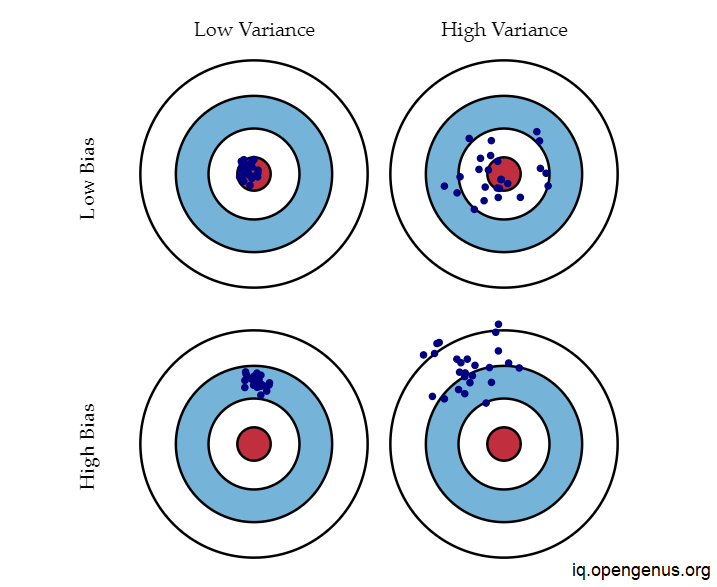

In [40]:
# Set up experiment: generate many datasets from the same distribution
n_datasets = 100  # Number of different datasets to generate
n_train = n_samples  # Use same training size as before
x_test = np.linspace(0, 10, 100)  # Dense test set for evaluation
X_test = design_matrix(x_test)
y_test_true = true_intercept + true_slope * x_test  # Noiseless test labels

# Generate multiple datasets and fit models of different complexities
polynomial_degrees = [0, 1, 3, 5] #np.arange(1, 8)  # Test degrees 1 through 7
predictions_all = {}  # Store predictions for each degree

for degree in polynomial_degrees:
    predictions_all[degree] = []

print(f"Generating {n_datasets} datasets and fitting models...")
for dataset_idx in range(n_datasets):
    # Generate new dataset from same distribution
    noise_new = np.random.normal(loc=0.0, scale=noise_scale, size=n_train)
    y_new = true_intercept + true_slope * x + noise_new
    
    # Fit polynomial models of different degrees
    for degree in polynomial_degrees:
        X_poly = np.vstack([x ** i for i in range(degree + 1)]).T
        X_poly_test = np.vstack([x_test ** i for i in range(degree + 1)]).T
        
        # Fit using least squares
        coeffs = np.linalg.lstsq(X_poly, y_new, rcond=None)[0]
        y_pred_test = X_poly_test @ coeffs
        
        predictions_all[degree].append(y_pred_test)

print("Experiment complete!")
# Convert to numpy arrays for easier computation
for degree in polynomial_degrees:
    predictions_all[degree] = np.array(predictions_all[degree])

print(f"\nPredictions shape for each degree: ({n_datasets}, {len(x_test)})")

Generating 100 datasets and fitting models...
Experiment complete!

Predictions shape for each degree: (100, 100)


In [41]:
# Compute bias-variance decomposition
# Bias² = (E[f_hat] - f_true)²
# Variance = E[(f_hat - E[f_hat])²]
# Expected Test Error = Bias² + Variance + Noise (irreducible error)

bias_squared = np.zeros(len(polynomial_degrees))
variance = np.zeros(len(polynomial_degrees))
test_error = np.zeros(len(polynomial_degrees))

for idx, degree in enumerate(polynomial_degrees):
    # Average prediction across all datasets
    mean_predictions = np.mean(predictions_all[degree], axis=0)
    
    # Bias squared: average squared deviation from true function
    bias_squared[idx] = np.mean((mean_predictions - y_test_true) ** 2)
    
    # Variance: average squared deviation from mean prediction
    deviations = predictions_all[degree] - mean_predictions[np.newaxis, :]
    variance[idx] = np.mean(deviations ** 2)
    
    # Test error: direct MSE on test set
    test_error[idx] = bias_squared[idx] + variance[idx]

results_df = pd.DataFrame({
    'Polynomial Degree': polynomial_degrees,
    'Bias²': bias_squared,
    'Variance': variance,
    'Test Error': test_error
})

print("Bias-Variance Decomposition:")
print(results_df.to_string(index=False))

Bias-Variance Decomposition:
 Polynomial Degree      Bias²  Variance  Test Error
                 0 104.146003  3.013747  107.159750
                 1   0.000627  5.265717    5.266345
                 3   0.006598 10.069628   10.076226
                 5   0.700425 17.810146   18.510570


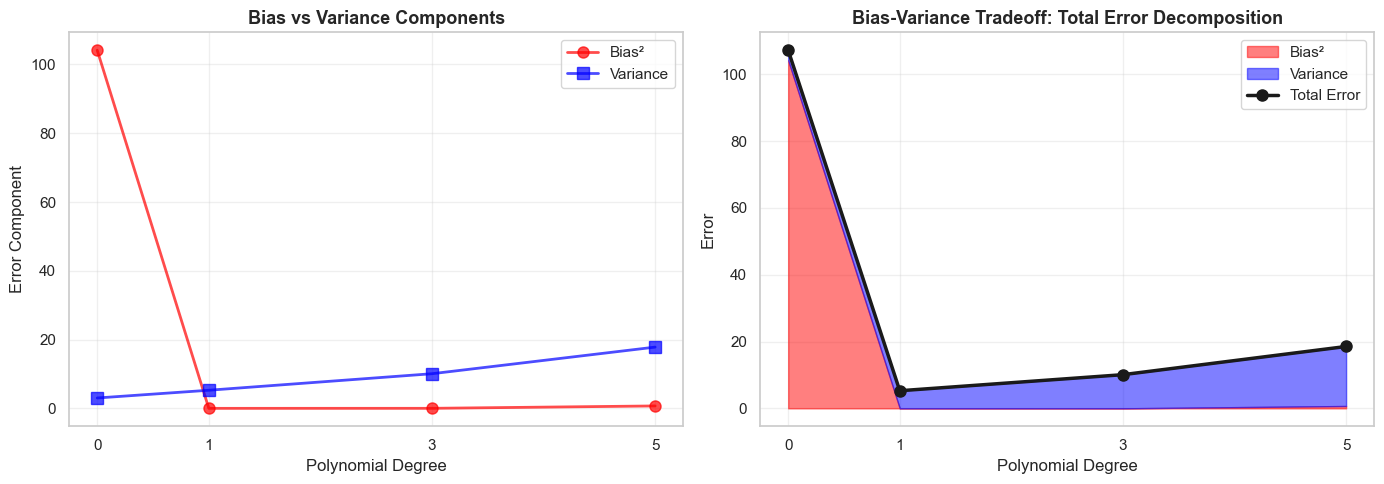


⭐ Optimal polynomial degree: 1 (lowest test error: 5.2663)


In [42]:
# Visualize the bias-variance tradeoff
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Bias² and Variance separately
ax1.plot(polynomial_degrees, bias_squared, 'o-', linewidth=2, markersize=8, label='Bias²', color='red', alpha=0.7)
ax1.plot(polynomial_degrees, variance, 's-', linewidth=2, markersize=8, label='Variance', color='blue', alpha=0.7)
ax1.set_xlabel('Polynomial Degree', fontsize=12)
ax1.set_ylabel('Error Component', fontsize=12)
ax1.set_title('Bias vs Variance Components', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(polynomial_degrees)

# Right plot: Decomposition of total error (stacked area + line)
ax2.fill_between(polynomial_degrees, 0, bias_squared, alpha=0.5, label='Bias²', color='red')
ax2.fill_between(polynomial_degrees, bias_squared, bias_squared + variance, alpha=0.5, label='Variance', color='blue')
ax2.plot(polynomial_degrees, test_error, 'ko-', linewidth=2.5, markersize=8, label='Total Error', zorder=5)
ax2.set_xlabel('Polynomial Degree', fontsize=12)
ax2.set_ylabel('Error', fontsize=12)
ax2.set_title('Bias-Variance Tradeoff: Total Error Decomposition', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(polynomial_degrees)

plt.tight_layout()
plt.show()

# Identify optimal model complexity
optimal_degree = polynomial_degrees[np.argmin(test_error)]
print(f"\n⭐ Optimal polynomial degree: {optimal_degree} (lowest test error: {np.min(test_error):.4f})")

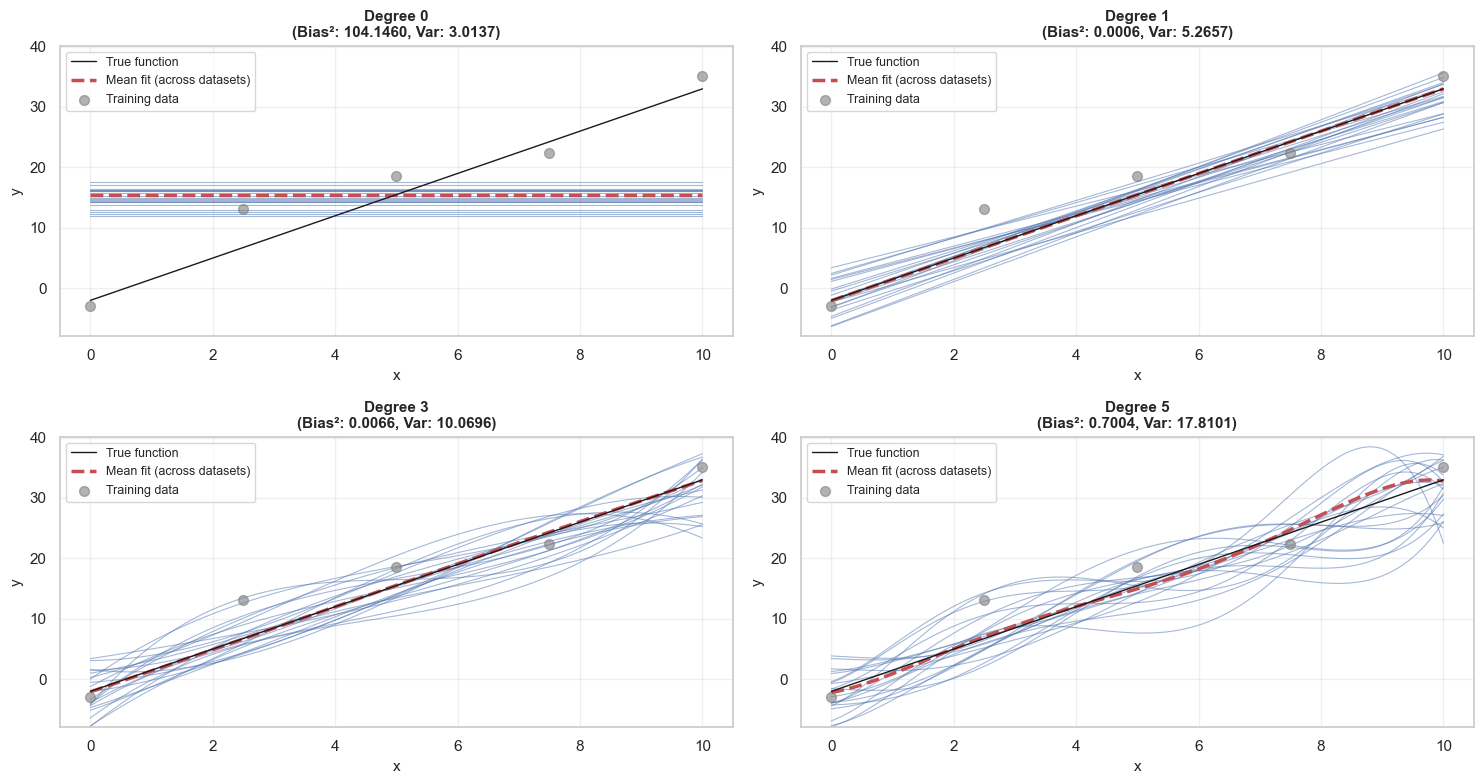


Interpretation: Bias-Variance Tradeoff Across Model Complexities
Degree 0: Bias²=104.1460, Variance=3.0137
  → HIGH BIAS, LOW VARIANCE (Underfitting)
  → Simple model cannot capture true relationship well

Degree 1: Bias²=0.0006, Variance=5.2657
  → BALANCED TRADEOFF
  → Better balance between bias and variance

Degree 3: Bias²=0.0066, Variance=10.0696
  → BALANCED TRADEOFF
  → Better balance between bias and variance

Degree 5: Bias²=0.7004, Variance=17.8101
  → LOW BIAS, HIGH VARIANCE (Overfitting)
  → Complex model fits noise, predictions vary widely



In [48]:
# Interpretation: Visualize underfitting vs overfitting
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.flatten()  # Flatten 2x2 grid to 1D array

# All polynomial degrees to plot
selected_degrees = polynomial_degrees  # [0, 1, 3, 5]

for ax_idx, degree in enumerate(selected_degrees):
    ax = axes[ax_idx]
    
    # Plot true function
    ax.plot(x_test, y_test_true, 'k-', linewidth=1, label='True function', zorder=10)
    
    # Plot multiple fits from different datasets (thin lines, semi-transparent)
    for dataset_idx in range(min(20, n_datasets)):  # Show first 20 fits for clarity
        ax.plot(x_test, predictions_all[degree][dataset_idx], 'b-', alpha=0.5, linewidth=0.8)
    
    # Plot mean prediction
    mean_pred = np.mean(predictions_all[degree], axis=0)
    ax.plot(x_test, mean_pred, 'r--', linewidth=2.5, label='Mean fit (across datasets)', zorder=5)
    
    # Plot original data points
    ax.scatter(x, y, alpha=0.6, s=50, color='gray', label='Training data', zorder=3)
    
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.set_title(f'Degree {degree}\n(Bias²: {bias_squared[ax_idx]:.4f}, Var: {variance[ax_idx]:.4f})', 
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([y.min() - 5, y.max() + 5])

plt.tight_layout()
plt.show()

print("\nInterpretation: Bias-Variance Tradeoff Across Model Complexities")
print("=" * 60)
for idx, degree in enumerate(selected_degrees):
    print(f"Degree {degree}: Bias²={bias_squared[idx]:.4f}, Variance={variance[idx]:.4f}")
    if idx == 0:
        print(f"  → HIGH BIAS, LOW VARIANCE (Underfitting)")
        print(f"  → Simple model cannot capture true relationship well\n")
    elif idx == len(selected_degrees) - 1:
        print(f"  → LOW BIAS, HIGH VARIANCE (Overfitting)")
        print(f"  → Complex model fits noise, predictions vary widely\n")
    else:
        print(f"  → BALANCED TRADEOFF")
        print(f"  → Better balance between bias and variance\n")